# 6. Decision Trees & Ensemble Learning

This week, we'll talk about decision trees & tree-based ensemble algorithms

In [1]:
# See Mentor's notebook, before writing code in Register.
#  (to See what to write in Register.)

## 6.1 Credit Risk Scoring Project

In [38]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

## 6.2 Data cleaning & preparation

- Downloading the dataset
- Re-encoding the categorical variables
- Doing the train/validation/test split

In [ ]:
# data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-06-trees/CreditScoring.csv'
data = 'CreditScoring.csv'

In [40]:
df = pd.read_csv(data)
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [41]:
df.columns = df.columns.str.lower()

In [42]:
df.status.value_counts()

status
1    3200
2    1254
0       1
Name: count, dtype: int64

In [43]:
status_values = {
    1: 'ok', 
    2: 'default', 
    0: 'unknown'
}
df.status = df.status.map(status_values)

In [44]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,1,60,30,2,1,3,73,129,0,0,800,846
1,ok,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,default,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,ok,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,ok,0,1,36,26,1,1,1,46,107,0,0,310,910


In [45]:
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

df.records = df.records.map(records_values)

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df.job = df.job.map(job_values)

In [46]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [47]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [48]:
df.income.max()

np.int64(99999999)

In [49]:
df.income.replace(to_replace=99999999, value=np.nan).max() 
# Don't ever write this code in Register.

np.float64(959.0)

In [50]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)

In [51]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [52]:
df = df[df.status != 'unknown'].reset_index(drop=True)
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4450,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4451,default,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4452,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


In [53]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df, test_size=0.25, random_state=11)

In [54]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [55]:
y_train = (df_train.status == 'default').astype('int').values
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

In [56]:
del df_train['status']
del df_val['status']
del df_test['status']

In [57]:
df_train

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,rent,36,24,married,no,partime,41,56.0,0.0,0.0,500,585
1,1,owner,60,24,single,no,fixed,35,70.0,4000.0,0.0,1200,1505
2,5,parents,36,45,married,yes,fixed,75,68.0,0.0,0.0,2375,2875
3,13,owner,60,27,married,no,fixed,60,112.0,3000.0,1485.0,800,1200
4,9,other,36,32,single,no,fixed,35,125.0,0.0,0.0,1000,1725
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3335,4,owner,60,47,married,no,freelance,75,0.0,13500.0,0.0,1900,1976
3336,2,rent,60,28,single,no,fixed,45,101.0,0.0,0.0,1300,1333
3337,2,parents,36,25,single,no,fixed,35,110.0,0.0,0.0,500,1200
3338,4,other,60,25,single,no,fixed,35,162.0,0.0,0.0,1800,2999


## 6.3 Decision Trees

- How a decision tree looks like
- Training a decision tree
- Overfitting
- Controlling the size of a tree

In [58]:
def assess_risk(client):
    if client['records'] == 'yes':
        if client['job'] == 'partime':
            return 'default'
        else:
            return 'ok'
    else:
        if client['assets'] > 6000:
            return 'ok'
        else:
            return 'default'

In [59]:
df_train.iloc[0].to_dict()

{'seniority': 1,
 'home': 'rent',
 'time': 36,
 'age': 24,
 'marital': 'married',
 'records': 'no',
 'job': 'partime',
 'expenses': 41,
 'income': 56.0,
 'assets': 0.0,
 'debt': 0.0,
 'amount': 500,
 'price': 585}

In [60]:
xi = df_train.iloc[0].to_dict()
assess_risk(xi)

'default'

In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

In [62]:
train_dicts = df_train.fillna(0).to_dict(orient='records')

In [63]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [64]:
X_train # Feature Matrix

array([[2.400e+01, 5.000e+02, 0.000e+00, ..., 0.000e+00, 1.000e+00,
        3.600e+01],
       [2.400e+01, 1.200e+03, 4.000e+03, ..., 0.000e+00, 1.000e+00,
        6.000e+01],
       [4.500e+01, 2.375e+03, 0.000e+00, ..., 1.000e+00, 5.000e+00,
        3.600e+01],
       ...,
       [2.500e+01, 5.000e+02, 0.000e+00, ..., 0.000e+00, 2.000e+00,
        3.600e+01],
       [2.500e+01, 1.800e+03, 0.000e+00, ..., 0.000e+00, 4.000e+00,
        6.000e+01],
       [2.500e+01, 1.800e+03, 0.000e+00, ..., 0.000e+00, 1.000e+00,
        4.800e+01]])

In [65]:
dv.get_feature_names_out()

array(['age', 'amount', 'assets', 'debt', 'expenses', 'home=ignore',
       'home=other', 'home=owner', 'home=parents', 'home=private',
       'home=rent', 'home=unk', 'income', 'job=fixed', 'job=freelance',
       'job=others', 'job=partime', 'job=unk', 'marital=divorced',
       'marital=married', 'marital=separated', 'marital=single',
       'marital=unk', 'marital=widow', 'price', 'records=no',
       'records=yes', 'seniority', 'time'], dtype=object)

In [66]:
dt = DecisionTreeClassifier() # dt => decision_tree
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [67]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [68]:
y_pred = dt.predict_proba(X_val)
y_pred

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [0., 1.]])

In [69]:
# roc_auc_score(y_val, y_pred) # Error, because 'y_pred' is 2-D array

In [70]:
y_pred = dt.predict_proba(X_val)[:, 1]
y_pred

array([1., 0., 0., ..., 0., 0., 1.])

In [71]:
# Training dataset
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

1.0

In [72]:
# Validation dataset
roc_auc_score(y_val, y_pred) # Works, because here 'y_pred' is 1-D array
# Overfitting, as y_pred on y_train = 1,
#             but y_pred on y_val = 0.66 

ValueError: Found input variables with inconsistent numbers of samples: [1114, 3340]

In [73]:
# Don't write this code cell, before Seeing Markdown (6.5: Decision Trees Parameter Tuning)


# dt = DecisionTreeClassifier(max_depth=1) # UR, & See O/P of this code cell & below 3-code cell
# dt = DecisionTreeClassifier(max_depth=2) # UR, & See O/P of this code cell & below 3-code cell
# dt = DecisionTreeClassifier(max_depth=3) # UR, & See O/P of this code cell & below 3-code cell
dt = DecisionTreeClassifier(max_depth=4) 
# dt = DecisionTreeClassifier(max_depth=5) # UR, & See O/P of this code cell & below 3-code cell
# dt = DecisionTreeClassifier(max_depth=6) # UR, & See O/P of this code cell & below 3-code cell
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [74]:
y_pred = dt.predict_proba(X_train)[:, 1]
auc_1 = roc_auc_score(y_train, y_pred)
print('train: ', auc_1)

y_pred = dt.predict_proba(X_val)[:, 1]
auc_2 = roc_auc_score(y_val, y_pred)
print('train: ', auc_2)

train:  0.8000466217904103
train:  0.7812557699182487


In [75]:
from sklearn.tree import export_text

In [76]:
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- records=no <= 0.50
|   |--- seniority <= 6.50
|   |   |--- seniority <= 1.50
|   |   |   |--- assets <= 4750.00
|   |   |   |   |--- class: 1
|   |   |   |--- assets >  4750.00
|   |   |   |   |--- class: 1
|   |   |--- seniority >  1.50
|   |   |   |--- amount <= 939.50
|   |   |   |   |--- class: 0
|   |   |   |--- amount >  939.50
|   |   |   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- income <= 109.50
|   |   |   |--- assets <= 4500.00
|   |   |   |   |--- class: 1
|   |   |   |--- assets >  4500.00
|   |   |   |   |--- class: 0
|   |   |--- income >  109.50
|   |   |   |--- price <= 505.00
|   |   |   |   |--- class: 1
|   |   |   |--- price >  505.00
|   |   |   |   |--- class: 0
|--- records=no >  0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 73.50
|   |   |   |--- assets <= 4250.00
|   |   |   |   |--- class: 0
|   |   |   |--- assets >  4250.00
|   |   |   |   |--- class: 0
|   |   |--- income >  73.50
|   |   |   |--- seniority <= 5.50
|   |   | 

## 6.4 Decision Tree learning algorithm

- Finding the best split for one column
- Finding the best split for the entire dataset
- Stopping criteria
- Decision tree learning algorithm

In [77]:
data = [
    [8000, 'default'],
    [2000, 'default'],
    [   0, 'default'],
    [5000, 'ok'],
    [5000, 'ok'],
    [4000, 'ok'],
    [9000, 'ok'],
    [3000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets', 'status'])
df_example

,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


In [78]:
# In Lecture-6.4, [03:07], df_Right => dataframe_Right

In [79]:
df_example = df_example.sort_values('assets')
df_example

,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


In [80]:
from IPython.display import display

In [81]:
T = 4000
df_left = df_example[df_example.assets <= T]
df_right = df_example[df_example.assets > T]

display(df_left)
print(df_left.status.value_counts(normalize=True)) # Gives Misclassification Rate
display(df_right)
print(df_right.status.value_counts(normalize=True)) # Gives Misclassification Rate

,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,status
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64


In [82]:
# Ts => Potential threshold to divide 'assets' column.
# Ts = [0, 2000, 3000, 4000, 5000, 8000, 9000] # 9000, not because it is at the end of 'assets' column.
Ts = [0, 2000, 3000, 4000, 5000, 8000] 

In [83]:
for T in Ts:
    print(T)
    df_left = df_example[df_example.assets <= T]
    df_right = df_example[df_example.assets > T]

    display(df_left)
    print(df_left.status.value_counts(normalize=True)) # Misclassification Rate
    display(df_right)
    print(df_right.status.value_counts(normalize=True)) # Misclassification Rate

    print()

0


,assets,status
2,0,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
1,2000,default
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64

2000


,assets,status
2,0,default
1,2000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64

3000


,assets,status
2,0,default
1,2000,default
7,3000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


status
ok         0.8
default    0.2
Name: proportion, dtype: float64

4000


,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,status
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64

5000


,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok


status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,status
0,8000,default
6,9000,ok


status
default    0.5
ok         0.5
Name: proportion, dtype: float64

8000


,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,status
6,9000,ok


status
ok    1.0
Name: proportion, dtype: float64



In [84]:
data = [
    [8000, 3000, 'default'],
    [2000, 1000, 'default'],
    [   0, 1000, 'default'],
    [5000, 1000, 'ok'],
    [5000, 1000, 'ok'],
    [4000, 1000, 'ok'],
    [9000,  500, 'ok'],
    [3000, 2000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets', 'debt', 'status'])
df_example

,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


In [85]:
df_example.sort_values('debt')

,assets,debt,status
6,9000,500,ok
1,2000,1000,default
3,5000,1000,ok
2,0,1000,default
5,4000,1000,ok
4,5000,1000,ok
7,3000,2000,default
0,8000,3000,default


In [86]:
thresholds = {
    'assets': [0, 2000, 3000, 4000, 5000, 8000],
    'debt': [500, 1000, 2000]
}

In [87]:
for feature, Ts in thresholds.items():
    print('###################')
    print(feature)
    for T in Ts:
        print(T)
        df_left = df_example[df_example[feature] <= T]
        df_right = df_example[df_example[feature] > T]

        display(df_left)
        print(df_left.status.value_counts(normalize=True)) # Misclassification Rate
        display(df_right)
        print(df_right.status.value_counts(normalize=True)) # Misclassification Rate

        print()
    print('###################')

###################
assets
0


,assets,debt,status
2,0,1000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64

2000


,assets,debt,status
1,2000,1000,default
2,0,1000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64

3000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
7,3000,2000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok


status
ok         0.8
default    0.2
Name: proportion, dtype: float64

4000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
5,4000,1000,ok
7,3000,2000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
6,9000,500,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64

5000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
6,9000,500,ok


status
default    0.5
ok         0.5
Name: proportion, dtype: float64

8000


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,debt,status
6,9000,500,ok


status
ok    1.0
Name: proportion, dtype: float64

###################
###################
debt
500


,assets,debt,status
6,9000,500,ok


status
ok    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64

1000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
7,3000,2000,default


status
default    1.0
Name: proportion, dtype: float64

2000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default


status
default    1.0
Name: proportion, dtype: float64

###################


In [88]:
# In Lecture-6.4, [23:00]-[26:00], Stopping Criteria for Decision-Tree (See it from Lecture.)

### Finding the best split algorithm:
- For F in features:
    - Find all Thresholds for F
    - For T in Thresholds:
        - Split dataset using "F > T" condition
        - Compute the impurity of this split
- Select the condition with the Lowest impurity

### Stopping Criteria for Decision-Tree split
- Group already pure (i.e. Misclassification rate = 0)
- Tree reached depth limit
- Group too small to split

### Decision Tree learning algorithm
- Find the best split
- Stop if max_depth is reached
- If Left is sufficiently large & not pure:
    - Repeat for Left
- If Right is sufficiently large & not pure:
    - Repeat for Right

### See this link to understand more things in Decision Trees
https://scikit-learn.org/stable/modules/tree.html

## 6.5 Decision Trees parameter tuning

- selecting `max_depth`
- selecting `min_samples_leaf`

In [89]:
# Lecture-6.5

In [90]:
DecisionTreeClassifier()

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [91]:
for d in [1, 2, 3, 4, 5, 6, 10, 15, 20, None]: # None => No height-limit, i.e. max_depth=INF(infinity(∞))
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)

    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    print('%4s -> %.3f' % (d, auc))

   1 -> 0.601
   2 -> 0.662
   3 -> 0.740
   4 -> 0.781
   5 -> 0.782
   6 -> 0.778
  10 -> 0.679
  15 -> 0.662
  20 -> 0.661
None -> 0.652


In [92]:
for d in [4, 5, 6]: # (d = [4, 5, 6]), best O/P from above code-cell.
    print('############')
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]: 
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)

        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        print('(%4s, %3d) -> %.3f' % (d, s, auc))
    print()

############
(   4,   1) -> 0.780
(   4,   2) -> 0.781
(   4,   5) -> 0.781
(   4,  10) -> 0.781
(   4,  15) -> 0.781
(   4,  20) -> 0.776
(   4, 100) -> 0.770
(   4, 200) -> 0.770
(   4, 500) -> 0.729

############
(   5,   1) -> 0.781
(   5,   2) -> 0.783
(   5,   5) -> 0.783
(   5,  10) -> 0.785
(   5,  15) -> 0.784
(   5,  20) -> 0.781
(   5, 100) -> 0.779
(   5, 200) -> 0.783
(   5, 500) -> 0.729

############
(   6,   1) -> 0.779
(   6,   2) -> 0.783
(   6,   5) -> 0.779
(   6,  10) -> 0.776
(   6,  15) -> 0.776
(   6,  20) -> 0.784
(   6, 100) -> 0.788
(   6, 200) -> 0.783
(   6, 500) -> 0.729



In [93]:
scores = []

# (d => depth, s => sample_size)

# for d in [4, 5, 6]: # UR & run below all code-cell of '6.5 Decision Trees Parameter Tuning'         
# (d = [4, 5, 6]), best O/P from above code-cell.         
for d in [4, 5, 6, 10, 15]: # Try every 'depth & min_samples_leaf' permutation.
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]: 
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)

        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d, s, auc))

In [94]:
columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

In [95]:
df_scores.sort_values(by='auc', ascending=False)

,max_depth,min_samples_leaf,auc
42,15,100,0.791389
33,10,100,0.791389
32,10,20,0.788109
24,6,100,0.787720
12,5,10,0.784835
13,5,15,0.784455
23,6,20,0.783876
14,5,20,0.783145
11,5,5,0.783130
16,5,200,0.783112


In [96]:
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', 
                                  columns=['max_depth'], 
                                  values=['auc'])
df_scores_pivot.round(3)

auc                            
max_depth            4      5      6      10     15
min_samples_leaf                                   
1                 0.781  0.782  0.781  0.687  0.670
2                 0.781  0.783  0.782  0.697  0.671
5                 0.779  0.783  0.783  0.726  0.722
10                0.781  0.785  0.779  0.756  0.753
15                0.779  0.784  0.776  0.763  0.770
20                0.776  0.783  0.784  0.788  0.783
100               0.770  0.779  0.788  0.791  0.791
200               0.770  0.783  0.783  0.783  0.783
500               0.729  0.729  0.729  0.729  0.729

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

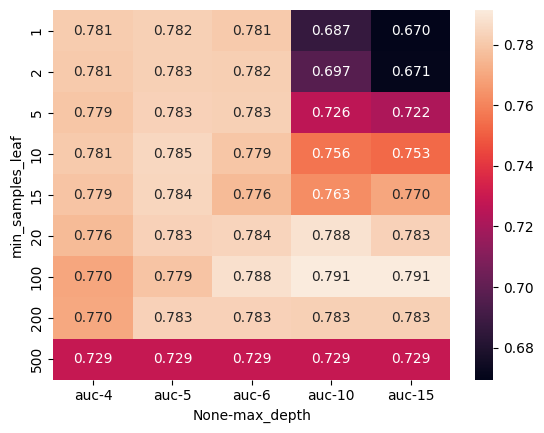

In [97]:
sns.heatmap(df_scores_pivot, annot=True, fmt='.3f') # annot => annotation, fmt => format

In [98]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

## 6.6 Ensembles & Random Forest

- Board of experts
- Ensembling models
- Random forest - ensembling decision trees
- Tuning random forest

In [99]:
# In Lecture-6.6, 
# [03:45], ((1/n) * ∑P[i])   (P[i] => Probability[i])
# [05:36], (DT#1 => Decision Tree no.-1)

In [100]:
from sklearn.ensemble import RandomForestClassifier

In [101]:
# (Run this cell & below 3-cells again & again, because of Randomisation in 
#  Random-Forest, which will give different answer each time.)

rf = RandomForestClassifier(n_estimators=10) # (rf => Random Forest)
#                            (↑)n_estimators=10, total no. of models
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [102]:
# Pseudo Random-Forest,         because of      (↓)random_state=1
#  (Gives same result everytime you run it.)

rf = RandomForestClassifier(n_estimators=10, random_state=1) # (rf => Random Forest)
#                            (↑)n_estimators=10, total no. of models
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [103]:
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7889594701299926

In [104]:
rf.predict_proba(X_val[[0]])

array([[0.9, 0.1]])

In [105]:
scores = []

for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))

In [106]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])
df_scores

,n_estimators,auc
0,10,0.788959
1,20,0.813554
2,30,0.819154
3,40,0.824007
4,50,0.827431
5,60,0.826616
6,70,0.828527
7,80,0.826808
8,90,0.827030
9,100,0.827828


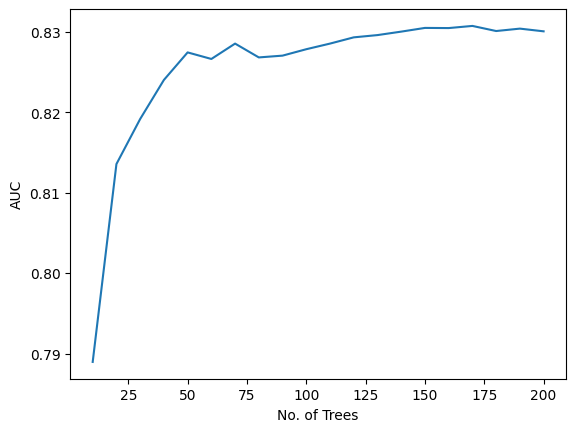

In [107]:
plt.xlabel("No. of Trees")
plt.ylabel("AUC")
plt.plot(df_scores.n_estimators, df_scores.auc)
# Local Maxima at (No. of Trees = 50) (i.e. n_estimators=50, is good)

In [108]:
scores = []

for d in [5, 10, 15]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=d,
                                    random_state=1) # Pseudo Random
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((d, n, auc))

In [109]:
columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores

,max_depth,n_estimators,auc
0,5,10,0.819097
1,5,20,0.822416
2,5,30,0.826779
3,5,40,0.824382
4,5,50,0.825887
5,5,60,0.825789
6,5,70,0.825093
7,5,80,0.825042
8,5,90,0.825042
9,5,100,0.825078


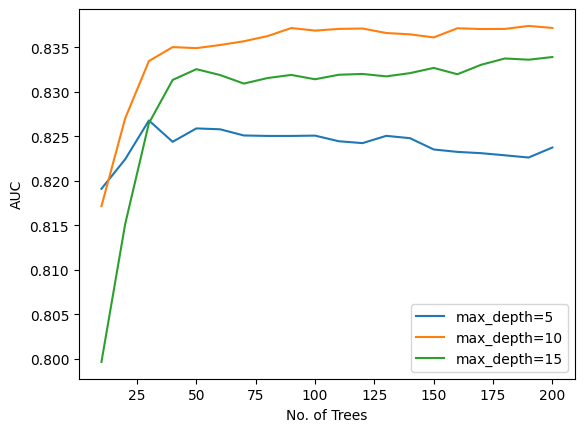

In [110]:
for d in [5, 10, 15]:
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.auc,
             label='max_depth=%d' % d)

plt.xlabel("No. of Trees")
plt.ylabel("AUC")
plt.legend()

In [111]:
max_depth = 10 # Best 'max_depth' from above graph.

In [112]:
scores = []

for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=max_depth,
                                    min_samples_leaf=s,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((s, n, auc))

In [113]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,min_samples_leaf,n_estimators,auc
0,1,10,0.817146
1,1,20,0.827022
2,1,30,0.833461
3,1,40,0.835032
4,1,50,0.834915


In [114]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
min_samples_leaf_values = [1, 3, 5, 10, 50]
list(zip(min_samples_leaf_values, colors))

[(1, 'black'), (3, 'blue'), (5, 'orange'), (10, 'red'), (50, 'grey')]

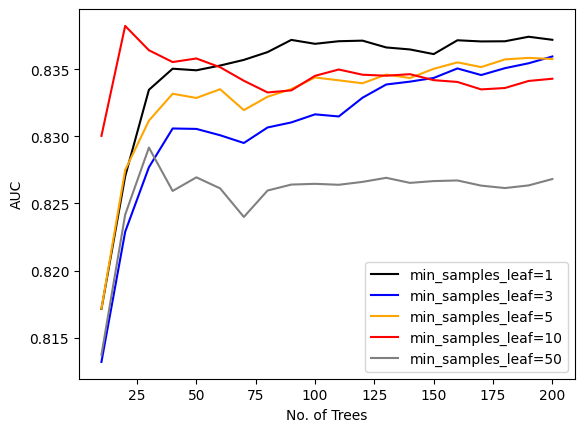

In [115]:
for s, col in zip(min_samples_leaf_values, colors): # col => color
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    plt.plot(df_subset.n_estimators, df_subset.auc,
             color=col,
             label='min_samples_leaf=%d' % s)

plt.xlabel("No. of Trees")
plt.ylabel("AUC")
plt.legend()

In [116]:
min_samples_leaf = 3 # Best from above Graph

In [117]:
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            random_state=1,
                            n_jobs=-1) # n_jobs => No. of jobs to run in Parallel
                            # (↑) n_jobs=-1, i.e. using all processors, to reduce time-taken.

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Other useful parameters:
- `max_features`
- `bootstrap`      
- (See from below link. (all Parameters & understand them))

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

## 6.7 Gradient Boosting & XGBoost

- Gradient Boosting vs Random Forest
- Installing XGBoost
- Training the first model
- Performance monitoring
- Parsing xgboost's monitoring output

In [118]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [119]:
import xgboost as xgb # type: ignore

In [120]:
features = dv.get_feature_names_out().tolist() # '.tolist()' => (numpy array -> list of strings)
d_train = xgb.DMatrix(X_train, label=y_train, feature_names=features) # d_train => DMatrix_train
d_val = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [121]:
xgb_params = { # params => parameters
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1, # => min_sample_size

    'objective': 'binary:logistic',
    'nthread': 8, # 'nthread' => No. of Parallel processor

    'seed': 1, # 'seed' => Randomization
    # 'verbosity': 0 # => Didn't show warning
    'verbosity': 1 # => Show the warning
}

# model = xgb.train(xgb_params, d_train, num_boost_round=100) # UR & run below 2 code-cell. 
#   (↑) Overfitting
model = xgb.train(xgb_params, d_train, num_boost_round=10) 
#                                       (↑) No._of_Trees, buids sequentially.

In [122]:
y_pred = model.predict(d_val)
y_pred

array([0.45232335, 0.22027665, 0.13314839, ..., 0.11457488, 0.32084718,
       0.7609319 ], dtype=float32)

In [123]:
roc_auc_score(y_val, y_pred)

0.8373187509084551

In [124]:
watchlist = [(d_train, 'train'), (d_val, 'val')]

In [125]:
%%capture output  
# (↑) CR (Comment & Run) (do both CR in this code at once, & then run code-cell)

xgb_params = { # params => parameters
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1, # => min_sample_size

    'objective': 'binary:logistic',
    'eval_metric': 'auc', # CR (Comment & Run)

    'nthread': 8, # 'nthread' => No. of Parallel processor
    'seed': 1, # 'seed' => Randomization
    # 'verbosity': 0 # => Didn't show warning
    'verbosity': 1 # => Show the warning
}

model = xgb.train(xgb_params, d_train, num_boost_round=200,
#                                       (↑) No._of_Trees, buids sequentially.
                  verbose_eval=5, # Train every 5th, num_boost_round
                  evals=watchlist)

In [126]:
print(output.stdout) # type: ignore

[0]	train-auc:0.84883	val-auc:0.79053
[5]	train-auc:0.91969	val-auc:0.83302
[10]	train-auc:0.94203	val-auc:0.83973
[15]	train-auc:0.95436	val-auc:0.83855
[20]	train-auc:0.96917	val-auc:0.83777
[25]	train-auc:0.97378	val-auc:0.83607
[30]	train-auc:0.97931	val-auc:0.83444
[35]	train-auc:0.98425	val-auc:0.83227
[40]	train-auc:0.98762	val-auc:0.83124
[45]	train-auc:0.99020	val-auc:0.82925
[50]	train-auc:0.99283	val-auc:0.82806
[55]	train-auc:0.99452	val-auc:0.82757
[60]	train-auc:0.99603	val-auc:0.82804
[65]	train-auc:0.99752	val-auc:0.82627
[70]	train-auc:0.99807	val-auc:0.82440
[75]	train-auc:0.99836	val-auc:0.82285
[80]	train-auc:0.99884	val-auc:0.82260
[85]	train-auc:0.99934	val-auc:0.82091
[90]	train-auc:0.99956	val-auc:0.81842
[95]	train-auc:0.99974	val-auc:0.81827
[100]	train-auc:0.99987	val-auc:0.81842
[105]	train-auc:0.99989	val-auc:0.81847
[110]	train-auc:0.99994	val-auc:0.81850
[115]	train-auc:0.99998	val-auc:0.81707
[120]	train-auc:0.99998	val-auc:0.81666
[125]	train-auc:0.9999

In [127]:
s = output.stdout # s => string    # type: ignore

In [128]:
print(s)

[0]	train-auc:0.84883	val-auc:0.79053
[5]	train-auc:0.91969	val-auc:0.83302
[10]	train-auc:0.94203	val-auc:0.83973
[15]	train-auc:0.95436	val-auc:0.83855
[20]	train-auc:0.96917	val-auc:0.83777
[25]	train-auc:0.97378	val-auc:0.83607
[30]	train-auc:0.97931	val-auc:0.83444
[35]	train-auc:0.98425	val-auc:0.83227
[40]	train-auc:0.98762	val-auc:0.83124
[45]	train-auc:0.99020	val-auc:0.82925
[50]	train-auc:0.99283	val-auc:0.82806
[55]	train-auc:0.99452	val-auc:0.82757
[60]	train-auc:0.99603	val-auc:0.82804
[65]	train-auc:0.99752	val-auc:0.82627
[70]	train-auc:0.99807	val-auc:0.82440
[75]	train-auc:0.99836	val-auc:0.82285
[80]	train-auc:0.99884	val-auc:0.82260
[85]	train-auc:0.99934	val-auc:0.82091
[90]	train-auc:0.99956	val-auc:0.81842
[95]	train-auc:0.99974	val-auc:0.81827
[100]	train-auc:0.99987	val-auc:0.81842
[105]	train-auc:0.99989	val-auc:0.81847
[110]	train-auc:0.99994	val-auc:0.81850
[115]	train-auc:0.99998	val-auc:0.81707
[120]	train-auc:0.99998	val-auc:0.81666
[125]	train-auc:0.9999

In [129]:
line = s.split('\n')[0]

In [130]:
line.split('\t')

['[0]', 'train-auc:0.84883', 'val-auc:0.79053']

In [131]:
num_iter, train_auc, val_auc = line.split('\t')

In [132]:
int(num_iter.strip('[]'))

0

In [133]:
float(train_auc.split(':')[1])

0.84883

In [134]:
float(val_auc.split(':')[1])

0.79053

In [135]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        iter_line, train_line, val_line = line.split('\t')

        iter = int(iter_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((iter, train, val))
    
    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [136]:
df_score = parse_xgb_output(output) # type: ignore
# df_score # UR
df_score.head()  # If you ever write this code-cell, then write this 
                  #  'df_score.head()', not 'df_score'

,num_iter,train_auc,val_auc
0,0,0.84883,0.79053
1,5,0.91969,0.83302
2,10,0.94203,0.83973
3,15,0.95436,0.83855
4,20,0.96917,0.83777


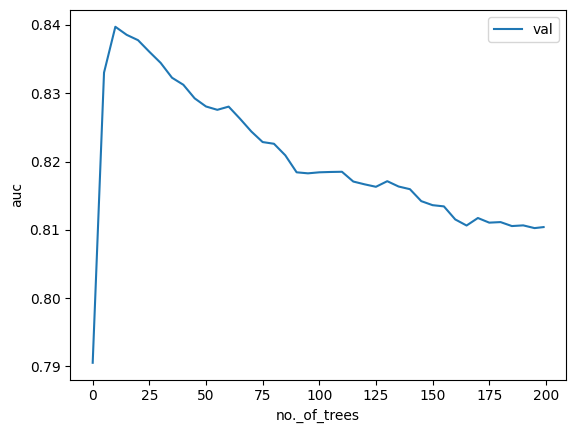

In [137]:
# plt.plot(df_score.num_iter, df_score.train_auc, label='train')   # UR
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.xlabel('no._of_trees')
plt.ylabel('auc')
plt.legend()

### See this link for better understanding of XGBoost,
https://xgboost.readthedocs.io/en/latest/parameter.html

## 6.8 XGBoost parameter tuning

Tuning the following parameters:
- `eta`
- `max_depth`
- `min_child_weight`

In [138]:
# Lecture-6.8

### Tuning 'eta'

In [139]:
scores_1 = {}

print("Scores")
for Eta in [0.01, 0.05, 0.1, 0.3, 0.7, 1.0]:
    xgb_params = { 
        'eta': Eta, # eta => Learning Rate 
        # (eta: 0.3,  i.e. 30% predictions in Model-2 are used to correct predictions in Model-1)
        'max_depth': 6,
        'min_child_weight': 1, 

        'objective': 'binary:logistic',
        'eval_metric': 'auc', 

        'nthread': 8, 
        'seed': 1, 
        'verbosity': 1 
    }

    print(f"\n{'='*60}")
    print(f"  eta = {Eta}")
    print(f"{'='*60}")

    evals_result = {}

    model = xgb.train(xgb_params, d_train, num_boost_round=200,
                    verbose_eval=5, 
                    evals=watchlist, evals_result=evals_result)
    
    key = 'eta=%s' % Eta
    scores_1[key] = evals_result # type: ignore

Scores

  eta = 0.01
[0]	train-auc:0.84883	val-auc:0.79053
[5]	train-auc:0.86052	val-auc:0.80371
[10]	train-auc:0.86296	val-auc:0.80781
[15]	train-auc:0.87051	val-auc:0.81511
[20]	train-auc:0.87579	val-auc:0.81657
[25]	train-auc:0.87734	val-auc:0.81680
[30]	train-auc:0.88094	val-auc:0.81954
[35]	train-auc:0.88475	val-auc:0.82149
[40]	train-auc:0.88659	val-auc:0.82238
[45]	train-auc:0.88786	val-auc:0.82269
[50]	train-auc:0.88867	val-auc:0.82347
[55]	train-auc:0.88991	val-auc:0.82320
[60]	train-auc:0.89247	val-auc:0.82480
[65]	train-auc:0.89492	val-auc:0.82477
[70]	train-auc:0.89704	val-auc:0.82552
[75]	train-auc:0.89887	val-auc:0.82544
[80]	train-auc:0.90054	val-auc:0.82575
[85]	train-auc:0.90201	val-auc:0.82601
[90]	train-auc:0.90332	val-auc:0.82601
[95]	train-auc:0.90462	val-auc:0.82616
[100]	train-auc:0.90593	val-auc:0.82628
[105]	train-auc:0.90718	val-auc:0.82677
[110]	train-auc:0.90846	val-auc:0.82707
[115]	train-auc:0.90980	val-auc:0.82767
[120]	train-auc:0.91115	val-auc:0.82869
[

In [140]:
# scores_1['eta=1.0']  # UR
# scores_1['eta=0.1']  # UR
# scores_1['eta=0.01'] # UR
scores_1

{'eta=0.01': {'train': OrderedDict([('auc',
                [0.8488285106274972,
                 0.851880746180197,
                 0.8584503219664332,
                 0.8584881715575018,
                 0.8585197870982767,
                 0.8605244795569906,
                 0.8608346235590995,
                 0.8610505888728436,
                 0.8619589790584892,
                 0.8624494652298071,
                 0.8629588761966593,
                 0.8636909318168561,
                 0.8667834660518112,
                 0.8679349841989089,
                 0.8682509169620048,
                 0.8705083111022647,
                 0.8720937636787309,
                 0.8731617900808245,
                 0.8745061184977185,
                 0.8751232894767895,
                 0.8757856573204894,
                 0.875902323118842,
                 0.876115616696746,
                 0.8764262059881616,
                 0.8768236266943815,
                 0.877342834025980

In [141]:
scores_1.keys()

dict_keys(['eta=0.01', 'eta=0.05', 'eta=0.1', 'eta=0.3', 'eta=0.7', 'eta=1.0'])

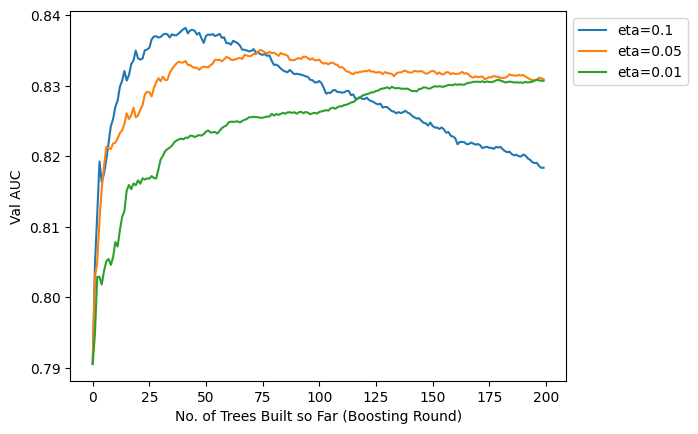

In [142]:
# etas = ['eta=1.0', 'eta=0.3', 'eta=0.1']  # UR
# etas = ['eta=0.1', 'eta=0.3', 'eta=0.01'] # UR
etas = ['eta=0.1', 'eta=0.05', 'eta=0.01']

for eta in etas:
    df_score = scores_1[eta]

    val_auc = df_score['val']['auc']
    num_iter = range(len(val_auc))
    plt.plot(num_iter, val_auc, label=eta)

plt.xlabel('No. of Trees Built so Far (Boosting Round)')
plt.ylabel('Val AUC')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

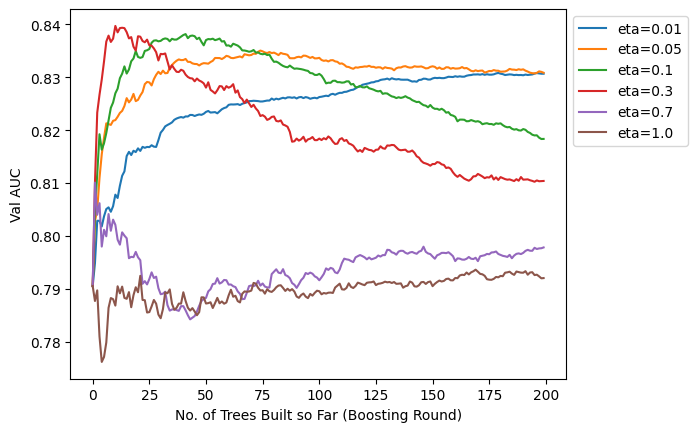

In [143]:
for key, df_score in scores_1.items():
    val_auc = df_score['val']['auc']
    num_iter = range(len(val_auc))
    plt.plot(num_iter, val_auc, label=key)
plt.xlabel('No. of Trees Built so Far (Boosting Round)')
plt.ylabel('Val AUC')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# plt.legend() # UR

# AUC (↓)decreases with (↑)increase in 'No. of Trees', because of overfitting.

In [144]:
eta = 0.3 # Best eta from above Graph, because it has higher 
          # peak & get its peak in less no. of Trees.

### Tuning 'max_depth'

In [145]:
# As we already tune 'eta' parameter, now we train on 2nd parameter
#  'max_depth'.

In [146]:
scores_2 = {}

print("Max. depth")
for max_depth in [3, 4, 6, 10]:
    xgb_params = { 
        'eta': 0.3, 
        'max_depth': max_depth,
        'min_child_weight': 1, 

        'objective': 'binary:logistic',
        'eval_metric': 'auc', 

        'nthread': 8, 
        'seed': 1, 
        'verbosity': 1 
    }

    print(f"\n{'='*60}")
    print(f"  max_depth = {max_depth}")
    print(f"{'='*60}")

    evals_result = {}

    model = xgb.train(xgb_params, d_train, num_boost_round=200,
                    verbose_eval=5, 
                    evals=watchlist, evals_result=evals_result)
    
    key = 'max_depth=%s' % max_depth
    scores_2[key] = evals_result # type: ignore

Max. depth

  max_depth = 3
[0]	train-auc:0.76253	val-auc:0.73656
[5]	train-auc:0.84378	val-auc:0.81275
[10]	train-auc:0.86879	val-auc:0.83297
[15]	train-auc:0.87834	val-auc:0.83187
[20]	train-auc:0.88708	val-auc:0.83549
[25]	train-auc:0.89249	val-auc:0.83663
[30]	train-auc:0.89937	val-auc:0.84023
[35]	train-auc:0.90460	val-auc:0.83699
[40]	train-auc:0.90849	val-auc:0.83706
[45]	train-auc:0.91158	val-auc:0.83742
[50]	train-auc:0.91638	val-auc:0.83526
[55]	train-auc:0.91837	val-auc:0.83543
[60]	train-auc:0.92232	val-auc:0.83384
[65]	train-auc:0.92477	val-auc:0.83237
[70]	train-auc:0.92778	val-auc:0.83280
[75]	train-auc:0.93044	val-auc:0.83206
[80]	train-auc:0.93391	val-auc:0.83097
[85]	train-auc:0.93485	val-auc:0.83060
[90]	train-auc:0.93842	val-auc:0.82932
[95]	train-auc:0.94161	val-auc:0.82879
[100]	train-auc:0.94343	val-auc:0.82810
[105]	train-auc:0.94492	val-auc:0.82701
[110]	train-auc:0.94677	val-auc:0.82580
[115]	train-auc:0.94869	val-auc:0.82480
[120]	train-auc:0.95038	val-auc:0.

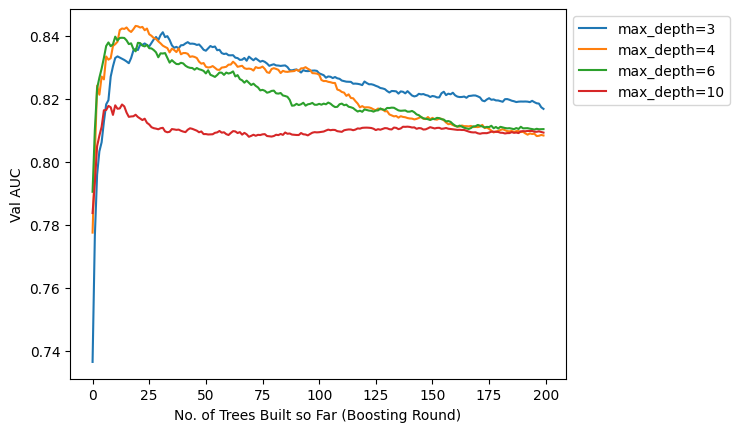

In [147]:
for max_depth, df_score in scores_2.items():
    val_auc = df_score['val']['auc']
    num_iter = range(len(val_auc))
    plt.plot(num_iter, val_auc, label=max_depth)
plt.xlabel('No. of Trees Built so Far (Boosting Round)')
plt.ylabel('Val AUC')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

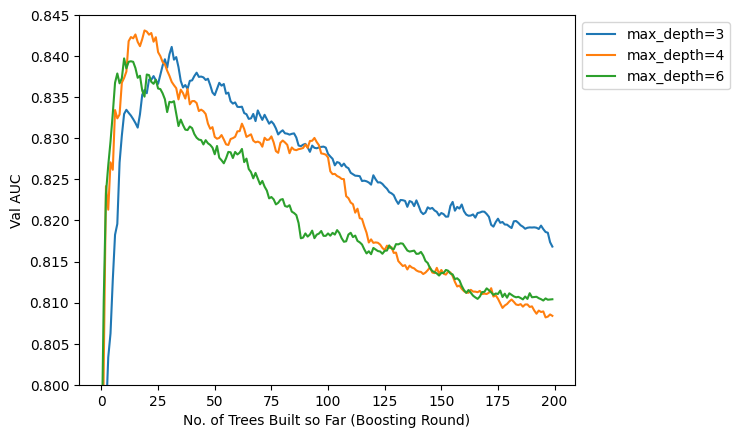

In [148]:
max_depths = ['max_depth=3', 'max_depth=4', 'max_depth=6']

for max_depth in max_depths:
    df_score = scores_2[max_depth]

    val_auc = df_score['val']['auc']
    num_iter = range(len(val_auc))
    plt.plot(num_iter, val_auc, label=max_depth)

plt.xlabel('No. of Trees Built so Far (Boosting Round)')
plt.ylabel('Val AUC')

plt.ylim(0.8, 0.845) # .ylim => y_limit
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

In [149]:
max_depth = 4 # Best max_depth (from above Graph)

### Tuning 'min_child_weight'

In [150]:
scores_3 = {}

print("Min. Child Weight")
for min_child_weight in [1, 10, 30]:
    xgb_params = { 
        'eta': 0.3, 
        'max_depth': 4,
        'min_child_weight': min_child_weight, 

        'objective': 'binary:logistic',
        'eval_metric': 'auc', 

        'nthread': 8, 
        'seed': 1, 
        'verbosity': 1 
    }

    print(f"\n{'='*60}")
    print(f"  min_child_weight = {min_child_weight}")
    print(f"{'='*60}")

    evals_result = {}

    model = xgb.train(xgb_params, d_train, num_boost_round=200,
                    verbose_eval=5, 
                    evals=watchlist, evals_result=evals_result)
    
    key = 'min_child_weight=%s' % min_child_weight
    scores_3[key] = evals_result # type: ignore

Min. Child Weight

  min_child_weight = 1
[0]	train-auc:0.80058	val-auc:0.77757


[5]	train-auc:0.87035	val-auc:0.82617
[10]	train-auc:0.89522	val-auc:0.83735
[15]	train-auc:0.90894	val-auc:0.84264
[20]	train-auc:0.91773	val-auc:0.84300
[25]	train-auc:0.92442	val-auc:0.84049
[30]	train-auc:0.92905	val-auc:0.83762
[35]	train-auc:0.93430	val-auc:0.83593
[40]	train-auc:0.93936	val-auc:0.83453
[45]	train-auc:0.94464	val-auc:0.83330
[50]	train-auc:0.94896	val-auc:0.83017
[55]	train-auc:0.95349	val-auc:0.82926
[60]	train-auc:0.95647	val-auc:0.83085
[65]	train-auc:0.95887	val-auc:0.83033
[70]	train-auc:0.96135	val-auc:0.82947
[75]	train-auc:0.96372	val-auc:0.83024
[80]	train-auc:0.96763	val-auc:0.82973
[85]	train-auc:0.97088	val-auc:0.82863
[90]	train-auc:0.97218	val-auc:0.82925
[95]	train-auc:0.97504	val-auc:0.82955
[100]	train-auc:0.97757	val-auc:0.82767
[105]	train-auc:0.97977	val-auc:0.82528
[110]	train-auc:0.98105	val-auc:0.82218
[115]	train-auc:0.98235	val-auc:0.82019
[120]	train-auc:0.98446	val-auc:0.81727
[125]	train-auc:0.98484	val-auc:0.81639
[130]	train-auc:0.98

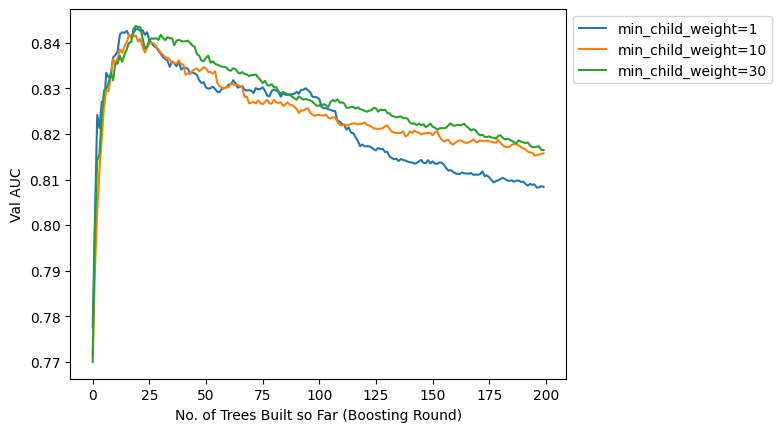

In [151]:
for min_child_weight, df_score in scores_3.items():
    val_auc = df_score['val']['auc']
    num_iter = range(len(val_auc))
    plt.plot(num_iter, val_auc, label=min_child_weight)
plt.xlabel('No. of Trees Built so Far (Boosting Round)')
plt.ylabel('Val AUC')

# plt.ylim(0.82, 0.845) # UR
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

In [152]:
min_child_weight = 1 
# Best, because all 3-values [1, 10, 30], have Graphs very close
#  to each other. So, it is better to take default 'min_child_weight'.

### Final Model

In [153]:
xgb_params = { 
    'eta': 0.3,             # Best value in this model
    'max_depth': 4,         # Best value in this model
    'min_child_weight': 1,  # Best value in this model

    'objective': 'binary:logistic',
    'eval_metric': 'auc', 

    'nthread': 8, 
    'seed': 1, 
    'verbosity': 1 
}

model = xgb.train(xgb_params, d_train, num_boost_round=35)
# (↑) num_boost_round=35 => because in all 3-Graphs of 'eta':0.3, 
#       'max_depth':4, 'min_child_weight':1, auc peaks at around
#       No. of Trees = 30.

In [154]:
# Learn, about 'Tuning XGBoost Parameter' from google,
#  or also see from 'Kaggle'.

Other parameters: https://xgboost.readthedocs.io/en/latest/parameter.html

Useful ones:
- `subsample` and `colsample_bytree`
- `lambda` and `alpha`

## 6.9 Selecting the final model

- Choosing between xgboost, random forest & decision tree
- Training the final model
- Saving the model

### Decision Tree model

In [155]:
# Decision Tree model
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [156]:
y_pred = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7756695069396157

### Random Forest model

In [157]:
# Random Forest model
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=10,
                            min_samples_leaf=3,
                            random_state=1,
                            n_jobs=-1) # n_jobs => No. of jobs to run in Parallel
                            # (↑) n_jobs=-1, i.e. using all processors, to reduce time-taken.

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [158]:
y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.8359437916661756

### XGBoost model

In [159]:
# XGBoost model
xgb_params = { 
    'eta': 0.3,             # Best value in this model
    'max_depth': 4,         # Best value in this model
    'min_child_weight': 1,  # Best value in this model

    'objective': 'binary:logistic',
    'eval_metric': 'auc', 

    'nthread': 8, 
    'seed': 1, 
    'verbosity': 1 
}

model = xgb.train(xgb_params, d_train, num_boost_round=35)
# (↑) num_boost_round=35 => because in all 3-Graphs of 'eta':0.3, 
#       'max_depth':4, 'min_child_weight':1, auc peaks at around
#       No. of Trees = 30.

In [160]:
y_pred = model.predict(X_val)[:, 1] # Error
roc_auc_score(y_val, y_pred)

TypeError: ('Expecting data to be a DMatrix object, got: ', <class 'numpy.ndarray'>)

In [161]:
# Wrap X_val in DMatrix first
d_val = xgb.DMatrix(X_val)
y_pred = model.predict(d_val, validate_features=False) 
#                               (↑) skip name check
roc_auc_score(y_val, y_pred)

0.8347397202154364

### AUC on Test data

In [162]:
df_full_train # Don't write in Register

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
3668,ok,22,owner,48,48,married,no,fixed,60,110.0,3000.0,0.0,1000,1460
2540,default,8,other,60,41,married,no,freelance,45,62.0,0.0,0.0,1800,2101
279,ok,2,parents,36,19,married,no,fixed,35,162.0,4000.0,100.0,400,570
3536,ok,1,owner,12,61,married,no,others,45,103.0,20000.0,0.0,300,650
3866,ok,13,owner,60,27,married,no,fixed,35,253.0,7000.0,0.0,1060,1750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332,default,4,owner,60,47,married,no,freelance,75,0.0,13500.0,0.0,1900,1976
1293,ok,2,rent,60,28,single,no,fixed,45,101.0,0.0,0.0,1300,1333
4023,ok,2,parents,36,25,single,no,fixed,35,110.0,0.0,0.0,500,1200
3775,ok,4,other,60,25,single,no,fixed,35,162.0,0.0,0.0,1800,2999


In [163]:
df_full_train = df_full_train.reset_index(drop=True)

In [164]:
y_full_train = (df_full_train.status == 'default').astype(int).values

In [165]:
y_full_train

array([0, 1, 0, ..., 0, 0, 1])

In [166]:
del df_full_train['status']

In [167]:
dicts_full_train = df_full_train.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

dicts_test = df_test.to_dict(orient='records')
X_test = dv.transform(dicts_test)

In [168]:
feature_names = list(dv.get_feature_names_out())

dfulltrain = xgb.DMatrix(X_full_train, label=y_full_train,
                        feature_names=feature_names)
dtest = xgb.DMatrix(X_test, feature_names=feature_names) 

In [169]:
# XGBoost model training on full_train
xgb_params = { 
    'eta': 0.3,             # Best value in this model
    'max_depth': 4,         # Best value in this model
    'min_child_weight': 1,  # Best value in this model

    'objective': 'binary:logistic',
    'eval_metric': 'auc', 

    'nthread': 8, 
    'seed': 1, 
    'verbosity': 1 
}

model = xgb.train(xgb_params, dfulltrain, num_boost_round=35)
#                               (↑) Change

In [170]:
dtest = xgb.DMatrix(X_test)
y_pred = model.predict(dtest, validate_features=False) 
roc_auc_score(y_test, y_pred)

0.8268596354039393

In [ ]:
import joblib

joblib.dump(model, "credit_risk_model.pkl")

## 6.10 Summary

- Decision trees learn if-then-else rules from data.
- Finding the best split: select the least impure split. This algorithm can overfit, that's why we
    control it by limiting the max depth & the size of the group
- Random forest is a way of combining multiple decision trees. It should have a diverse set of
    models to make good predictions.
- Gradient boosting trains model sequentially: each model tries to fix error of the previous
    models. XGBoost is an implementation of gradient boosting.